# Function 1

<b> Description of the Sample Application:</b> Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [7]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
input       = np.load(input_file)
output      = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", input.shape)
print("Inputs:\n", input)
print()

# Analyse the Output Data
print("Output Shape:", output.shape)
print("Outputs:\n", output)
print()
print("Minimum and Maximum Values of Output:\n")
print("Min:", output.min(), " Max:", output.max())
print("Best point:", input[np.argmax(output)], "-> Output =", output.max())
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(input, columns = [f'Input_{i+1}' for i in range(input.shape[1])])
df['Output'] = output
print("Data Frame:\n", df)


Input  Shape: (10, 2)
Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]

Output Shape: (10,)
Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]

Minimum and Maximum Values of Output:

Min: -0.0036060626443634764  Max: 7.710875114502849e-16
Best point: [0.73102363 0.73299988] -> Output = 7.710875114502849e-16

Data Frame:
     Input_1   Input_2         Output
0  0.319404  0.762959   1.322677e-79
1  0.574329  0.879898   1.033078e-46
2  0.731024  0.733000   7.710875e-16
3  0.840353  0.264732  3.341771e-124
4  0.650114  0.681526  -3.606063e-03
5  0.410437  0.147554  -2.159249e-54
6  0.312691  0.078723  -2.089093e-91
7  0.683418  0.861057   2.535001e-40


# Data Exploration

In [9]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
          Input_1    Input_2        Output
count  10.000000  10.000000  1.000000e+01
mean    0.548817   0.539519 -3.606063e-04
std     0.259160   0.296007  1.140337e-03
min     0.082507   0.078723 -3.606063e-03
25%     0.342162   0.299421 -1.566820e-91
50%     0.612222   0.631890  6.793724e-80
75%     0.719122   0.755469  7.903833e-47
max     0.883890   0.879898  7.710875e-16


In [10]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 Input_1    0
Input_2    0
Output     0
dtype: int64


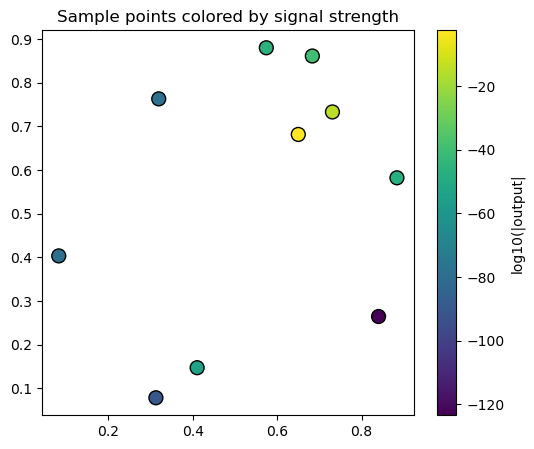

In [15]:
# Scatter Plot
magnitude = np.log10(np.abs(output) + 1e-300)
fig, ax   = plt.subplots(figsize = (6,5))
sc        = ax.scatter(input[:,0], input[:,1], c = magnitude, cmap = 'viridis', s = 100, edgecolor = 'black')
plt.colorbar(sc, label = 'log10(|output|')
ax.set_title('Sample points colored by signal strength')
plt.show()

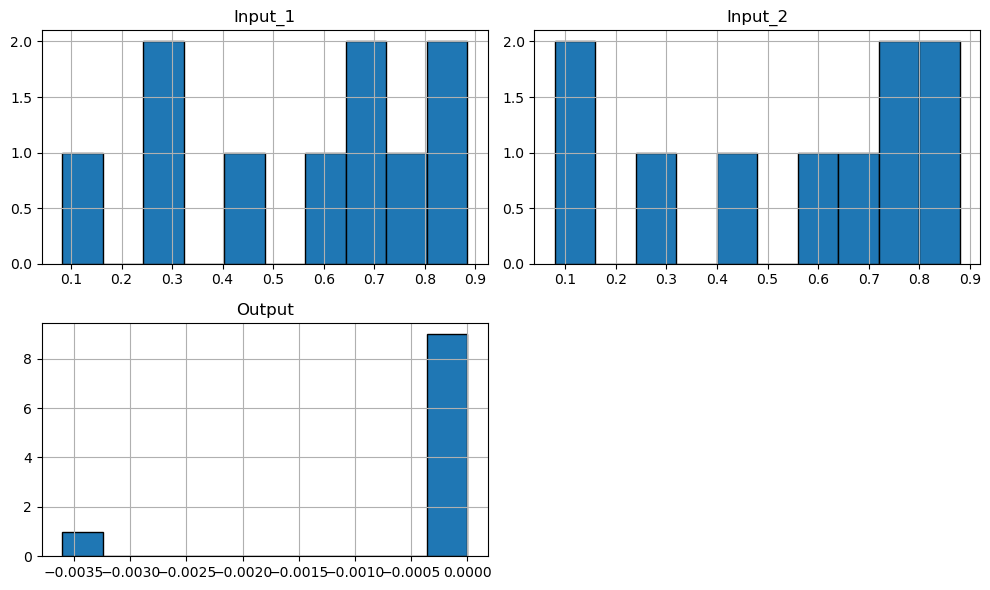

In [16]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'black' )
plt.tight_layout()
plt.show()

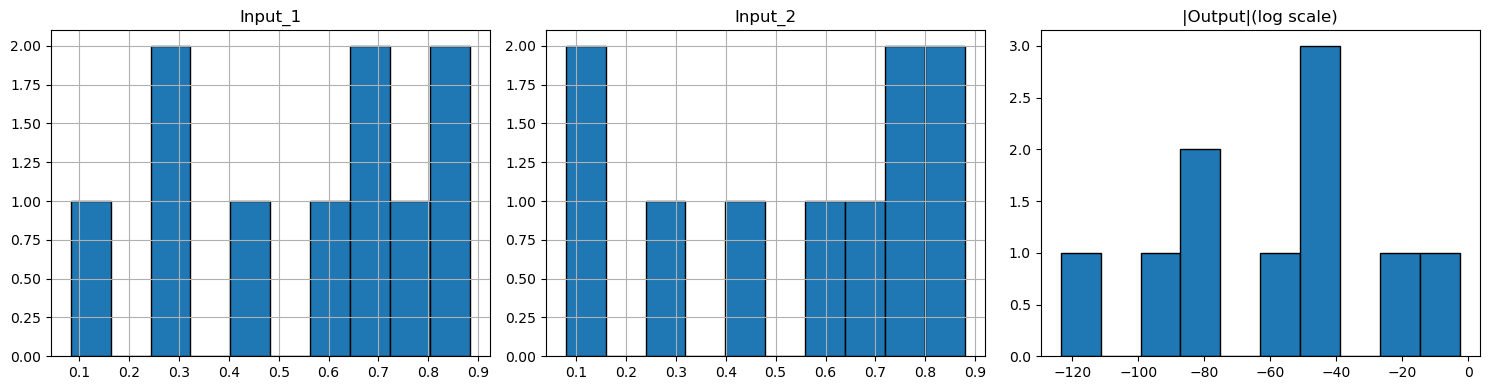

In [18]:
# In the above histogram for the output column, almost every bar seems to be crammed into a single bin near zero, which is not very informative.
# Plotting the column histograms using log scale for Output column
fig, axes = plt.subplots(1,3, figsize = (15,4))

df['Input_1'].hist(ax = axes[0], bins = 10, edgecolor = 'black')
axes[0].set_title('Input_1')

df['Input_2'].hist(ax = axes[1], bins = 10, edgecolor = 'black')
axes[1].set_title('Input_2')

magnitude = np.where(output != 0, np.log10(np.abs(output) + 1e-300), np.nan)
axes[2].hist(magnitude, bins = 10, edgecolor = 'black')
axes[2].set_title('|Output|(log scale)')


plt.tight_layout()
plt.show()

# Initialize Gaussian Process

In [20]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0) * RBF(length_scale = 0.2, length_scale_bounds = (0.02, 1.0)) \
                + WhiteKernel(noise_level = 1e-6, noise_level_bounds = (1e-10, 1e-2))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [23]:
# Train the model
X = input
y = output
gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.995**2 * RBF(length_scale=0.02) + WhiteKernel(noise_level=0.00992)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.02. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [29]:
grid_res   = 150
xs         = np.linspace(0, 1, grid_res)
ys         = np.linspace(0, 1, grid_res)
gx, gy     = np.meshgrid(xs, ys)
candidates = np.column_stack([gx.ravel(), gy.ravel()])

mu, std    = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta       = 2.5
ucb        = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.6442953  0.87248322]
Predicted Mean(μ): -3.151098e-04
Predicted Std (σ): 1.073450e-03
UCB Score: 2.368516e-03


# Perform Visualisation

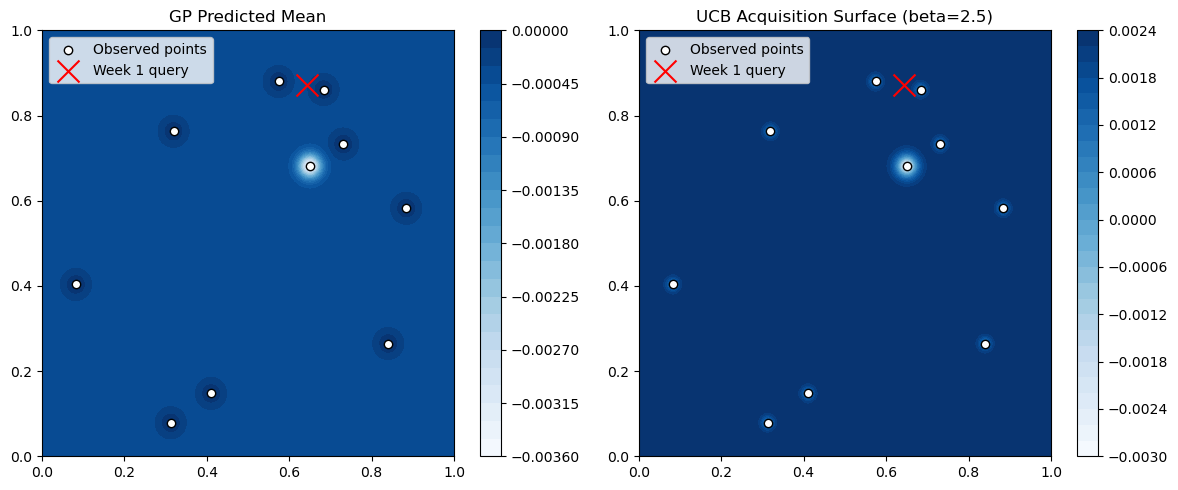

In [32]:
fig, axes  = plt.subplots(1,2, figsize = (12, 5))

# Predicted mean surface
c0 = axes[0].contourf(gx, gy, mu.reshape(gx.shape), levels=30, cmap="Blues")
axes[0].scatter(X[:, 0], X[:, 1], c="white", edgecolor="black", label="Observed points")
axes[0].scatter(*next_point, c="red", marker="x", s=250, label="Week 1 query")
axes[0].set_title("GP Predicted Mean")
axes[0].legend(loc='upper left')
fig.colorbar(c0, ax=axes[0])

# UCB acquisition surface
c1 = axes[1].contourf(gx, gy, ucb.reshape(gx.shape), levels=30, cmap="Blues")
axes[1].scatter(X[:, 0], X[:, 1], c="white", edgecolor="black", label="Observed points")
axes[1].scatter(*next_point, c="red", marker="x", s=250, label="Week 1 query")
axes[1].set_title("UCB Acquisition Surface (beta=2.5)")
axes[1].legend(loc='upper left')
fig.colorbar(c1, ax=axes[1])

plt.tight_layout()
plt.show()


# Portal Submission 

In [35]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.644295-0.872483

